In [2]:
import numpy as np
from scipy.optimize import minimize
from scipy.integrate import simpson
import matplotlib.pyplot as plt


In [11]:
#-----------------------------------------Initial conditions for Figure 8------------------------------------------
M = np.array([1, 1, 1])

x0 = np.array([
    [ 0.97000436, -0.24308753, 0.0],
    [-0.97000436,  0.24308753, 0.0],
    [ 0.0,         0.0,        0.0]
])

v0 = np.array([
    [ 0.4662036850,  0.4323657300, 0.0],
    [ 0.4662036850,  0.4323657300, 0.0],
    [-0.93240737,   -0.86473146,   0.0]
])


In [4]:
#-----------------------------------------Initial Conditions for Two Body Problem----------------------------------
M = np.array([1, 1])
N = np.size(M)
G = 1


#Initial conditions for Figure 8 
x0 = np.array([[ 0.5, 0, 0],
               [-0.5, 0, 0]])


R = np.linalg.norm(x0[1]-x0[0])
totalM = M[0] + M[1]
v_esc = np.sqrt(2 * G * totalM / R) #Escape Velocity
v_rel = np.sqrt(G * totalM / R) #Circular Velocity

v0= np.array([[0, 1.0*M[1]/totalM * v_rel, 0],
            [0, -1.0*M[0]/totalM * v_rel, 0]])


In [12]:
def acceleration(x, M, G):
    N = np.shape(x)[0]
    a = np.zeros((N, 3))
    U = 0
    collapse = False
    
    for i in range(N):
        for j in range(i+1, N):
            x_i, x_j = x[i, :], x[j, :]
            r_ij = x_j - x_i
            r_ij_norm = np.linalg.norm(r_ij) + 1e-7
            
            if r_ij_norm < 1e-7 or r_ij_norm > 20:
                collapse = True

            #Calculate force exerted on i by each j
            a_ij = G*M[i]*M[j]/(r_ij_norm**3) * (r_ij)
            a[i, :] += a_ij/M[i]
            a[j, :] -= a_ij/M[j]
            
            #Calculating potentials
            U_ij = -G*M[i]*M[j]/(r_ij_norm)
            U += U_ij 

    return a, U, collapse

In [13]:
def timestep(x, v, eta, N): #Max dt = 1
    dt = 1
    for i in range(N):
        for j in range(i+1, N):
            x_i, x_j = x[i, :], x[j, :]
            r_ij = x_j - x_i
            v_i, v_j = v[i, :], v[j, :]
            v_ij = v_j - v_i
            dt_ij = np.linalg.norm(r_ij)/(np.linalg.norm(v_ij)+1e-7)
            dt = np.minimum(dt, dt_ij)
    return eta*dt

In [14]:
def KickDriftKick(x, v, dt, constants):
    M, G, c1, c2, c3, c4, d1, d2, d3 = constants
    #First Step
    x_int1 = x + c1*v*dt
    a_int1, _, _ = acceleration(x_int1, M, G)
    v_int1 = v + d1*a_int1*dt

    #Second Step
    x_int2 = x_int1 + c2*v_int1*dt
    a_int2, _, _ = acceleration(x_int2, M, G)
    v_int2 = v_int1 + d2*a_int2*dt

    #Third Step
    x_int3 = x_int2 + c3*v_int2*dt
    a_int3, _, _ = acceleration(x_int3, M, G)
    v_int3 = v_int2 + d3*a_int3*dt

    #Final Step
    x_kp1 = x_int3 + c4*v_int3*dt
    _, U_int4, collapse = acceleration(x_kp1, M, G)
    v_kp1 = v_int3
    return x_kp1, v_kp1, U_int4, collapse

In [ ]:
def nBodyYoshidaVT_Plots(M, G, x0, v0, timesteps, eta):
    #Initialise
    N = np.size(M)
    colors = plt.cm.viridis(np.linspace(0, 1, N))
    time = np.zeros(timesteps)
    t_collapse = timesteps
    
    #Yoshida Coefficients
    w0 = -((2)**(1/3))/(2-2**(1/3))
    w1 = 1/(2-2**(1/3))
    c1 = w1/2
    c2 = (w0+w1)/2
    c3 = (w0+w1)/2
    c4 = w1/2
    d1 = w1
    d2 = w0
    d3 = w1

    constants = [M, G, c1, c2, c3, c4, d1, d2, d3]

    #Centre of Mass
    CoM0 = np.zeros(3)
    v_CoM0 = np.zeros(3)
    total_mass = np.sum(M, axis= 0)
    
    for i in range(N):
        CoM0 += M[i] * x0[i, :]/total_mass
        v_CoM0 += M[i] * v0[i, :]/total_mass

    _, U0, _ = acceleration(x0, M, G)

    #Position/Velocity Vectors
    x = np.zeros((N, 3, timesteps))
    v = np.zeros((N, 3, timesteps))
    
    x[:, :, 0] = x0-CoM0
    v[:, :, 0] = v0-v_CoM0

    #Conserved Quantities
    E = np.zeros(timesteps)
    T = np.zeros(timesteps) # KE
    U = np.zeros(timesteps) # PE
    P = np.zeros((3, timesteps)) # Momentum
    L = np.zeros((3, timesteps)) #Angular Momentum

    T[0] = np.sum(0.5*M*np.linalg.norm(v[:, :, 0], axis = 1)**2)
    U[0] = U0 
    E[0] = T[0] + U[0]
    P[:, 0] = np.sum(M[:, None] * v[:, :, 0], axis=0)
    L[:, 0] = np.sum(np.cross(x[:, :, 0], M[:, None] * v[:, :, 0]), axis=0)

    #Errors
    E_error = np.zeros(timesteps)
    P_error = np.zeros(timesteps)
    L_error = np.zeros(timesteps)

    E_error_denominator = np.absolute(E[0])
    P_error_denominator = np.linalg.norm(P[:, 0])
    L_error_denominator = np.linalg.norm(L[:, 0])

    #Check for zeros
    if np.linalg.norm(P[:, 0]) == 0:
        for i in range(N):
            v0_i = v0[i, :]
            if np.linalg.norm(v0_i) != 0:
                P_error_denominator = np.linalg.norm(M[i]*v0_i)
                break
    
    if np.linalg.norm(L[:, 0]) == 0:
        for i in range(N):
            x0_i = x0[i, :]
            v0_i = v0[i, :]
            P0_i = M[i]*v0_i
            L0_i = np.cross(x0_i, P0_i)
            if np.linalg.norm(L0_i) != 0:
                L_error_denominator = np.linalg.norm(L0_i)
                break

    for k in range(timesteps-1):
        #Finding dt
        dt_forward = timestep(x[:, :, k], v[:, :, k], eta, N)
        x_forward, v_forward, _, _ = KickDriftKick(x[:, :, k], v[:, :, k], dt_forward, constants)
        dt_back = timestep(x_forward, v_forward, eta, N)
        dt = (dt_forward+dt_back)/2
        time[k+1] = time[k] + dt

        #Using dt to find x, v
        x[:, :, k+1], v[:, :, k+1], U[k+1], collapse= KickDriftKick(x[:, :, k], v[:, :, k], dt, constants)
        
        #Update Conserved Quantities
        T[k+1] = np.sum(0.5*M*(np.linalg.norm(v[:, :, k+1], axis = 1)**2))
        E[k+1] = T[k+1] + U[k+1]
        P[:, k+1] = np.sum(M[:, None] * v[:, :, k+1], axis=0)
        L[:, k+1] = np.sum(np.cross(x[:, :, k+1], M[:, None] * v[:, :, k+1]), axis=0)

        #Check Errors
        E_error[k+1] = np.absolute((E[k+1]-E[0]))/E_error_denominator
        P_error[k+1] = np.linalg.norm(P[:, k+1] - P[:, 0])/P_error_denominator
        L_error[k+1] = np.linalg.norm(L[:, k+1] - L[:, 0])/L_error_denominator

        if P_error[k+1] > 1e-10:
            return f"Linear Momentum Error Too High, {P_error[k+1]*100}%"
        if L_error[k+1] > 1e-10:
            return f"Angular Momentum Error Too High, {L_error[k+1]*100}%"
        if E_error[k+1] > 1e-3:
            return f"Energy Error Too High, {E_error[k+1]*100}%"
        
        #Check for system collapse
        if collapse == True:
            print("System has collapsed")
            t_collapse = k
            break

    # Plotting the orbits
    fig1, axa = plt.subplots()
    #axa.scatter(0, 0, color = 'black', label = "Centre of Mass")
    for i in range(N):
        axa.plot(x[i, 0, 0:t_collapse], x[i, 1, 0:t_collapse], color = colors[i], label = f"Body {i+1}")
        axa.scatter(x[i, 0, 0], x[i, 1, 0], color = colors[i], label = f"Mass {i} Start ")
        axa.scatter(x[i, 0, -1], x[i, 1, -1], facecolor = 'None', edgecolor = colors[i], label = f"Mass {i} End ")
        plt.gca().set_aspect('equal', adjustable='box')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5)) 

    time = time[0:t_collapse]
    fig2, axb = plt.subplots(3, 1, figsize = (8, 8))
    axb[0].plot(time, 100*E_error)
    axb[0].set_title("Energy Error")
    axb[0].set_ylabel("Error (%)")
    axb[0].set_xlabel("Time") 
    axb[1].plot(time, 100*P_error)
    axb[1].set_title("Momentum Error")
    axb[1].set_ylabel("Error (%)")
    axb[1].set_xlabel("Time") 
    axb[2].plot(time, 100*L_error)
    axb[2].set_title("Ang. Momentum Error")
    axb[2].set_ylabel("Error (%)")
    axb[2].set_xlabel("Time") 
    plt.tight_layout()
    return x, v

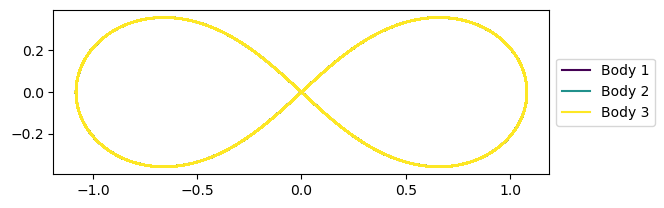

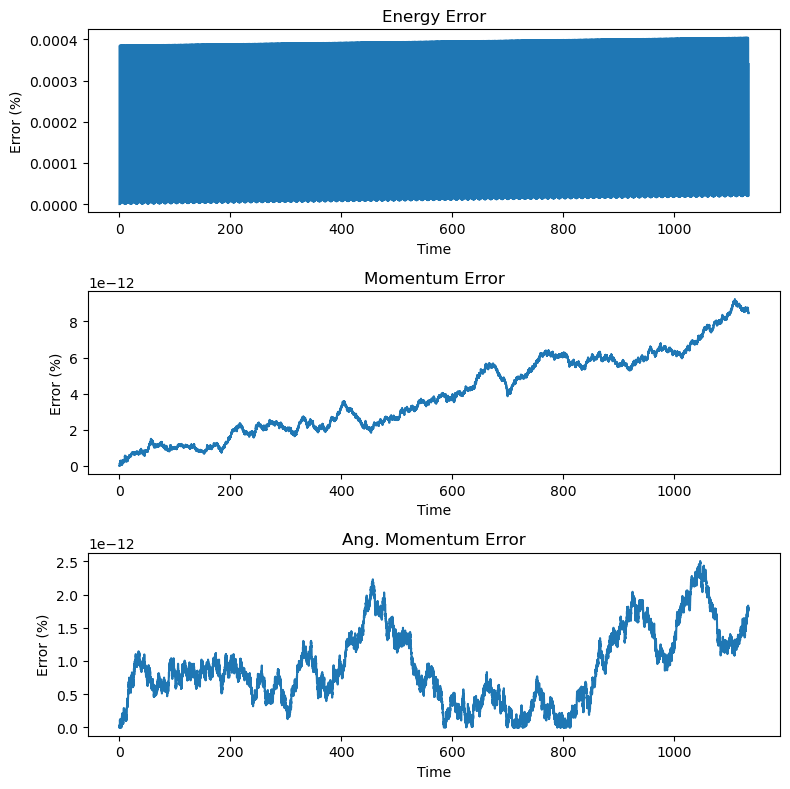

In [51]:
x, v = nBodyYoshidaVT_Plots(M, G, x0, v0, 30000, 0.1)
